In [58]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers,Sequential


In [59]:
(X_train,_),(_,_) = tf.keras.datasets.mnist.load_data()


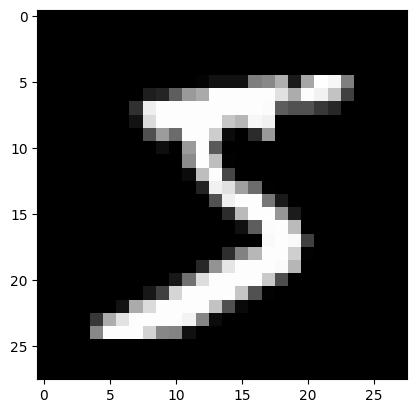

In [60]:
import matplotlib.pyplot as plt 
plt.imshow(X_train[0],cmap='gray')
plt.show()

In [61]:
X_train[0].shape


(28, 28)

In [62]:
X_train = X_train.astype('float32')/255.0

In [63]:
#Generator
latend_dim = 100
generator = keras.Sequential([
    layers.Input(shape=(latend_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28,1))
])

generator.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 128)               12928     
                                                                 
 dense_13 (Dense)            (None, 784)               101136    
                                                                 
 reshape_4 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
Total params: 114,064
Trainable params: 114,064
Non-trainable params: 0
_________________________________________________________________


In [64]:
#discriminator
discriminator = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_14 (Dense)            (None, 128)               100480    
                                                                 
 dense_15 (Dense)            (None, 1)                 129       
                                                                 
Total params: 100,609
Trainable params: 100,609
Non-trainable params: 0
_________________________________________________________________


In [65]:
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])

In [66]:

discriminator.trainable = False

gan_input = keras.Input(shape=(latend_dim,))
fake_img = generator(gan_input)

gan_output = discriminator(fake_img)

gan = keras.Model(gan_input,gan_output)

In [67]:
gan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])

In [68]:
X_train.shape

(60000, 28, 28)

In [ ]:
epochs=5000
batch_size=128 

for epoch in range(epochs):
    #Train Discriminator
    idx = np.random.randint(0,X_train.shape[0],batch_size)
    real_images = X_train[idx]

    noise = np.random.normal(0,1, (batch_size,latend_dim))
    fake_img = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_img, np.zeros((batch_size,1)))

    #Train Generator
    noise = np.random.normal(0,1, (batch_size,latend_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch} |"
            f"D Loss: {d_loss_real[0]:.4f} |"
            f"G Loss:{g_loss[0]:.4f}|"
        )


Epoch: 0 |D Loss: 1.0485 |G Loss:1.1145|
